# Test 22: Обоснование коэффициентов sin(a·x) + w·tanh(b·x)

**Вопрос научрука:** Почему именно такие коэффициенты? Есть ли закономерность?

**Гипотеза:** Оптимальный параметр a связан с частотным содержанием данных.
Данные с быстрой динамикой (хаос) → высокий a. Гладкие данные (MNIST, GPT-2) → низкий a.

**План:**
1. Спектральный анализ 4 доменов данных — измерить характерную частоту
2. 2D sweep a × w на каждом домене (a ∈ [0.5, 1, 2, 4, 8, 16], w ∈ [0.1, 0.25, 0.5, 0.75, 1.0])
3. Найти оптимальный a для каждого домена
4. Проверить корреляцию: a_opt ~ f(спектральная характеристика данных)
5. b=4 фиксирован (тест 9 показал слабое влияние с насыщением)

**Домены:** Logistic Map, Lorenz-96, MNIST, синусоиды (из теста 18)

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
from scipy.fft import fft, fftfreq
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# === Генерация данных для 4 доменов ===

def generate_logistic_map(n_samples=5000, dim=64, r=3.99):
    """Логистическая карта — хаотическая динамика."""
    data = []
    for _ in range(n_samples):
        x = np.random.rand()
        seq = []
        for _ in range(dim + 100):
            x = r * x * (1 - x)
            seq.append(x)
        data.append(seq[100:100+dim])
    return np.array(data, dtype='float32')

def generate_lorenz96(n_samples=5000, dim=64, F=8.0, dt=0.005, steps=2000):
    """Lorenz-96 — хаотическая система с защитой от взрыва."""
    N = dim
    data = []
    attempts = 0
    while len(data) < n_samples and attempts < n_samples * 3:
        attempts += 1
        x = np.random.randn(N) * 0.01
        x[0] += F
        blown = False
        for _ in range(steps):
            dx = np.zeros(N)
            for i in range(N):
                dx[i] = (x[(i+1)%N] - x[(i-2)%N]) * x[(i-1)%N] - x[i] + F
            x = x + dt * dx
            if np.any(np.abs(x) > 1e6) or np.any(np.isnan(x)):
                blown = True
                break
        if not blown and np.all(np.isfinite(x)):
            data.append(x.copy())
    if len(data) < n_samples:
        print(f"  Warning: got {len(data)}/{n_samples} valid Lorenz-96 samples")
    return np.array(data[:n_samples], dtype='float32')

def generate_sinusoidal(n_samples=5000, dim=64):
    """Суперпозиция синусоид — гладкие данные."""
    data = []
    t = np.linspace(0, 2*np.pi, dim)
    for _ in range(n_samples):
        n_waves = np.random.randint(2, 6)
        signal = np.zeros(dim)
        for _ in range(n_waves):
            freq = np.random.uniform(0.5, 5.0)
            amp = np.random.uniform(0.2, 1.0)
            phase = np.random.uniform(0, 2*np.pi)
            signal += amp * np.sin(freq * t + phase)
        data.append(signal)
    return np.array(data, dtype='float32')

def load_mnist_flat(dim=64):
    """MNIST → плоский вектор, обрезанный до dim."""
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_all = np.concatenate([x_train, x_test]).astype('float32') / 255.0
    x_flat = x_all.reshape(x_all.shape[0], -1)[:, :dim]
    return x_flat

# Генерация
np.random.seed(42)
domains = {
    'Logistic Map': generate_logistic_map(5000, 64),
    'Lorenz-96': generate_lorenz96(5000, 64),
    'Sinusoidal': generate_sinusoidal(5000, 64),
    'MNIST': load_mnist_flat(64),
}

for name, data in domains.items():
    has_nan = np.any(np.isnan(data)) or np.any(np.isinf(data))
    print(f"{name:15s}: shape={data.shape}, range=[{data.min():.3f}, {data.max():.3f}], "
          f"std={data.std():.3f}, nan/inf={has_nan}")

Logistic Map   : shape=(5000, 64), range=[0.010, 0.998], std=0.340, nan/inf=False
Lorenz-96      : shape=(5000, 64), range=[-12.220, 15.148], std=3.758, nan/inf=False
Sinusoidal     : shape=(5000, 64), range=[-4.013, 3.800], std=0.852, nan/inf=False
MNIST          : shape=(70000, 64), range=[0.000, 1.000], std=0.009, nan/inf=False


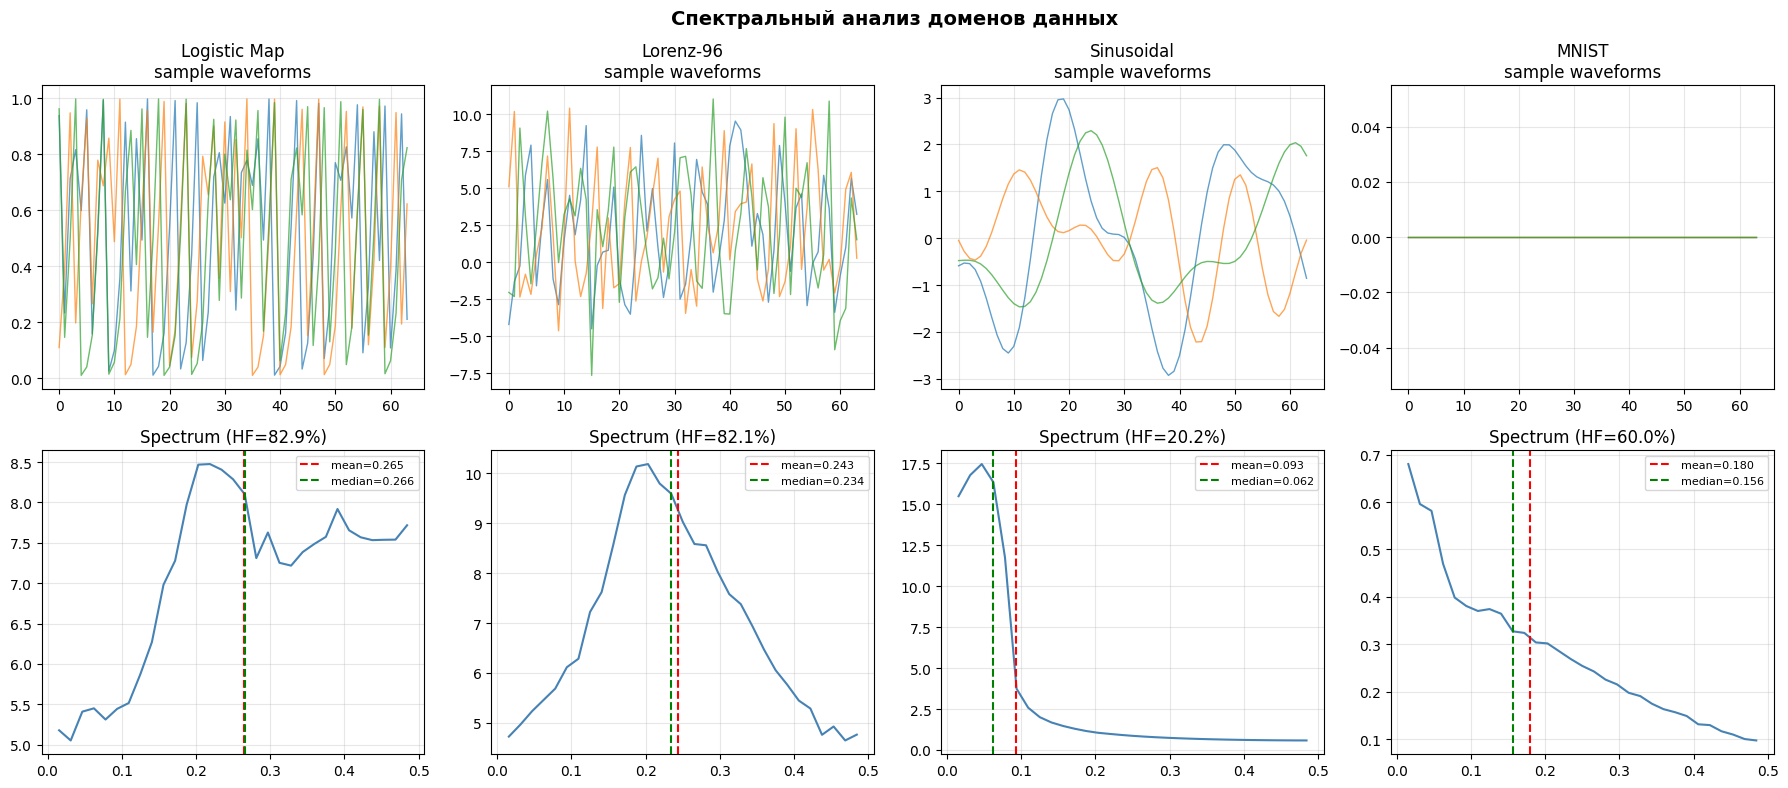


Спектральные характеристики:
Домен            Mean freq  Median freq   HF ratio
--------------------------------------------------
Logistic Map        0.2650       0.2656     82.9%
Lorenz-96           0.2434       0.2344     82.1%
Sinusoidal          0.0930       0.0625     20.2%
MNIST               0.1797       0.1562     60.0%


In [8]:
# === Спектральный анализ доменов ===

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

spectral_stats = {}

for i, (name, data) in enumerate(domains.items()):
    # Нормализация перед FFT
    data_norm = (data - data.mean(axis=0)) / (data.std(axis=0) + 1e-8)
    
    # FFT по каждому сэмплу, усреднение спектра
    spectra = []
    for sample in data_norm[:1000]:  # первые 1000 для скорости
        sp = np.abs(fft(sample))[:len(sample)//2]
        spectra.append(sp)
    mean_spectrum = np.mean(spectra, axis=0)
    freqs = fftfreq(len(data[0]), d=1.0)[:len(data[0])//2]
    
    # Характерная частота — средневзвешенная
    total_power = np.sum(mean_spectrum[1:])  # без DC
    mean_freq = np.sum(freqs[1:] * mean_spectrum[1:]) / total_power
    # Медианная частота — 50% мощности
    cumsum = np.cumsum(mean_spectrum[1:])
    median_idx = np.searchsorted(cumsum, total_power * 0.5)
    median_freq = freqs[1:][min(median_idx, len(freqs)-2)]
    # Высокочастотная доля (>0.25 Nyquist)
    hf_power = np.sum(mean_spectrum[len(mean_spectrum)//4:]) / total_power
    
    spectral_stats[name] = {
        'mean_freq': float(mean_freq),
        'median_freq': float(median_freq),
        'hf_power_ratio': float(hf_power),
        'total_power': float(total_power),
    }
    
    # Визуализация сэмплов
    axes[0, i].plot(data[0], alpha=0.7, lw=1)
    axes[0, i].plot(data[1], alpha=0.7, lw=1)
    axes[0, i].plot(data[2], alpha=0.7, lw=1)
    axes[0, i].set_title(f'{name}\nsample waveforms')
    axes[0, i].grid(True, alpha=0.3)
    
    # Спектр
    axes[1, i].plot(freqs[1:], mean_spectrum[1:], color='steelblue', lw=1.5)
    axes[1, i].axvline(x=mean_freq, color='red', ls='--', lw=1.5, label=f'mean={mean_freq:.3f}')
    axes[1, i].axvline(x=median_freq, color='green', ls='--', lw=1.5, label=f'median={median_freq:.3f}')
    axes[1, i].set_title(f'Spectrum (HF={hf_power:.1%})')
    axes[1, i].legend(fontsize=8)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Спектральный анализ доменов данных', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nСпектральные характеристики:")
print(f"{'Домен':15s} {'Mean freq':>10} {'Median freq':>12} {'HF ratio':>10}")
print('-' * 50)
for name, s in spectral_stats.items():
    print(f"{name:15s} {s['mean_freq']:>10.4f} {s['median_freq']:>12.4f} {s['hf_power_ratio']:>9.1%}")

In [9]:
# === SAE компоненты (упрощённая архитектура для sweep) ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask
    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def build_sae(input_dim, latent_dim, k_active, a=1.0, w=0.5, b=4.0):
    """Простой SAE для sweep: input → latent → output."""
    def act_fn(x):
        return tf.sin(a * x) + w * tf.tanh(b * x)
    
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim, name='latent_pre')(inp)
    x = layers.Activation(act_fn)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(inp, latent, name='encoder')
    decoded = layers.Dense(input_dim, name='decoder')(latent)
    autoencoder = keras.Model(inp, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("SAE ready.")

SAE ready.


In [10]:
# === 2D Sweep a × w по 4 доменам ===

A_VALUES = [0.5, 1, 2, 4, 8, 16]
W_VALUES = [0.1, 0.25, 0.5, 0.75, 1.0]
B_FIXED = 4.0
NUM_RUNS = 3
EPOCHS = 10
BATCH_SIZE = 128
INPUT_DIM = 64
LATENT_DIM = 128
K_ACTIVE = 32

sweep_results = {}

for domain_name, data in domains.items():
    print(f"\n{'='*70}")
    print(f"  ДОМЕН: {domain_name}")
    print(f"{'='*70}")
    
    # Нормализация
    data_norm = (data - data.mean(axis=0)) / (data.std(axis=0) + 1e-8)
    np.random.seed(42)
    idx = np.random.permutation(len(data_norm))
    split = int(len(idx) * 0.8)
    x_train = data_norm[idx[:split]]
    x_test = data_norm[idx[split:]]
    
    domain_results = {}
    
    for a in A_VALUES:
        for w in W_VALUES:
            losses = []
            deads = []
            for run in range(NUM_RUNS):
                np.random.seed(run)
                tf.random.set_seed(run)
                
                ae, enc = build_sae(INPUT_DIM, LATENT_DIM, K_ACTIVE, a=float(a), w=float(w), b=B_FIXED)
                ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                       validation_data=(x_test, x_test), verbose=0)
                
                latents = enc.predict(x_test, verbose=0)
                val_loss = float(ae.evaluate(x_test, x_test, verbose=0))
                dead = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
                
                losses.append(val_loss)
                deads.append(dead)
                
                del ae, enc
                keras.backend.clear_session()
            
            domain_results[(a, w)] = {
                'loss_mean': np.mean(losses),
                'loss_std': np.std(losses),
                'dead_mean': np.mean(deads),
            }
            
            print(f"  a={a:>5}, w={w:>4}: loss={np.mean(losses):.4f}±{np.std(losses):.4f}, dead={np.mean(deads):.1f}")
    
    sweep_results[domain_name] = domain_results

print("\n2D sweep завершён.")


  ДОМЕН: Logistic Map
  a=  0.5, w= 0.1: loss=0.2016±0.0007, dead=0.0
  a=  0.5, w=0.25: loss=0.1969±0.0017, dead=0.0
  a=  0.5, w= 0.5: loss=0.1966±0.0011, dead=0.0
  a=  0.5, w=0.75: loss=0.2035±0.0009, dead=0.0
  a=  0.5, w= 1.0: loss=0.2107±0.0020, dead=0.0
  a=    1, w= 0.1: loss=0.2012±0.0013, dead=0.0
  a=    1, w=0.25: loss=0.1973±0.0015, dead=0.0
  a=    1, w= 0.5: loss=0.1981±0.0015, dead=0.0
  a=    1, w=0.75: loss=0.2028±0.0010, dead=0.0
  a=    1, w= 1.0: loss=0.2067±0.0012, dead=0.0
  a=    2, w= 0.1: loss=0.6797±0.0031, dead=0.0
  a=    2, w=0.25: loss=0.6882±0.0051, dead=0.0
  a=    2, w= 0.5: loss=0.6852±0.0031, dead=0.0
  a=    2, w=0.75: loss=0.6906±0.0070, dead=0.0
  a=    2, w= 1.0: loss=0.6886±0.0045, dead=0.0
  a=    4, w= 0.1: loss=0.9133±0.0016, dead=0.0
  a=    4, w=0.25: loss=0.8927±0.0013, dead=0.0
  a=    4, w= 0.5: loss=0.8839±0.0013, dead=0.0
  a=    4, w=0.75: loss=0.8727±0.0029, dead=0.0
  a=    4, w= 1.0: loss=0.8649±0.0027, dead=0.0
  a=    8, w= 0.1

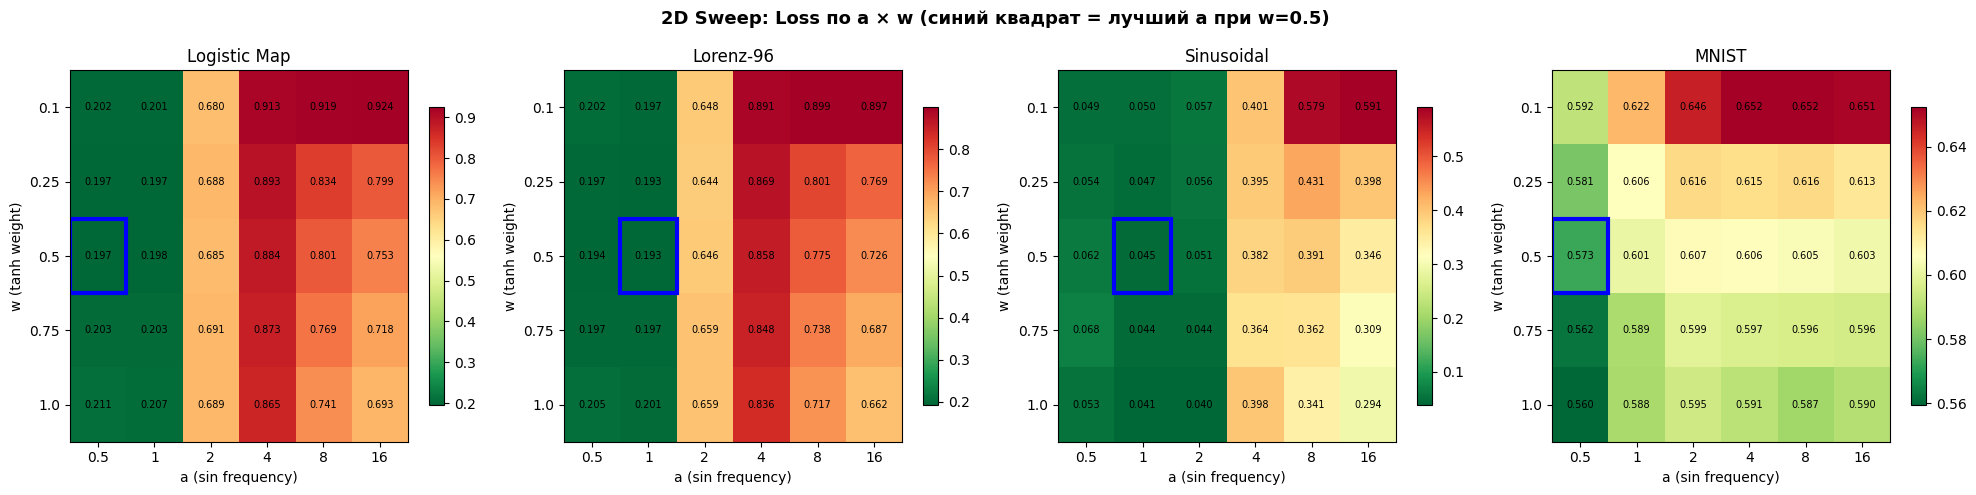


Оптимальный a при w=0.5:
  Logistic Map   : a = 0.5
  Lorenz-96      : a = 1
  Sinusoidal     : a = 1
  MNIST          : a = 0.5


In [11]:
# === Визуализация: Heatmaps loss по a × w для каждого домена ===

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

optimal_a = {}

for idx, (domain_name, domain_results) in enumerate(sweep_results.items()):
    # Матрица loss
    loss_matrix = np.zeros((len(W_VALUES), len(A_VALUES)))
    for i, w in enumerate(W_VALUES):
        for j, a in enumerate(A_VALUES):
            loss_matrix[i, j] = domain_results[(a, w)]['loss_mean']
    
    im = axes[idx].imshow(loss_matrix, cmap='RdYlGn_r', aspect='auto')
    axes[idx].set_xticks(range(len(A_VALUES)))
    axes[idx].set_xticklabels(A_VALUES)
    axes[idx].set_yticks(range(len(W_VALUES)))
    axes[idx].set_yticklabels(W_VALUES)
    axes[idx].set_xlabel('a (sin frequency)')
    axes[idx].set_ylabel('w (tanh weight)')
    axes[idx].set_title(f'{domain_name}')
    plt.colorbar(im, ax=axes[idx], shrink=0.8)
    
    # Аннотации
    for i in range(len(W_VALUES)):
        for j in range(len(A_VALUES)):
            axes[idx].text(j, i, f'{loss_matrix[i,j]:.3f}', ha='center', va='center', fontsize=7)
    
    # Лучший a (при фиксированном w=0.5, стандартное значение)
    w_idx = W_VALUES.index(0.5)
    losses_at_w05 = [domain_results[(a, 0.5)]['loss_mean'] for a in A_VALUES]
    best_a_idx = np.argmin(losses_at_w05)
    best_a = A_VALUES[best_a_idx]
    optimal_a[domain_name] = best_a
    axes[idx].add_patch(plt.Rectangle((best_a_idx-0.5, w_idx-0.5), 1, 1, 
                                       fill=False, edgecolor='blue', lw=3))

plt.suptitle('2D Sweep: Loss по a × w (синий квадрат = лучший a при w=0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nОптимальный a при w=0.5:")
for name, a in optimal_a.items():
    print(f"  {name:15s}: a = {a}")

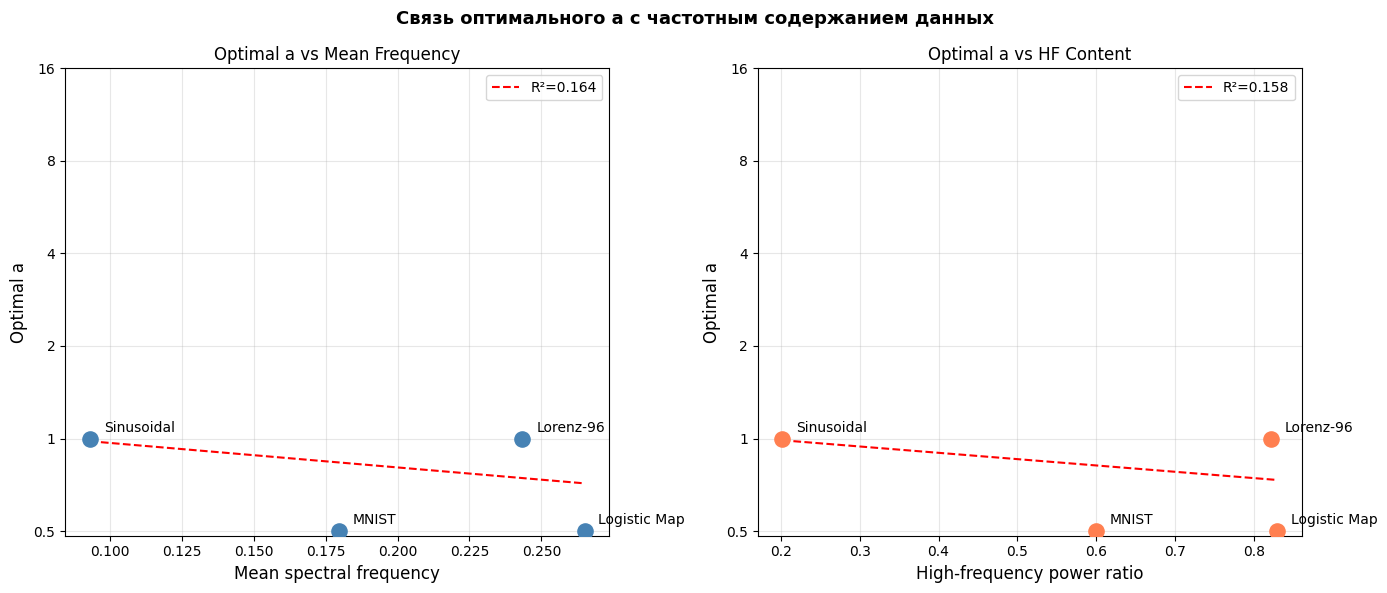


СВЯЗЬ: спектр данных → оптимальный a
Домен            Mean freq   HF ratio    Opt a      Тип данных
-----------------------------------------------------------------
Logistic Map        0.2650     82.9%      0.5     хаотические
Lorenz-96           0.2434     82.1%        1     хаотические
Sinusoidal          0.0930     20.2%        1         гладкие
MNIST               0.1797     60.0%      0.5     хаотические


In [12]:
# === Корреляция: оптимальный a vs спектральная характеристика ===

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

domain_names = list(domains.keys())
a_opts = [optimal_a[n] for n in domain_names]
mean_freqs = [spectral_stats[n]['mean_freq'] for n in domain_names]
hf_ratios = [spectral_stats[n]['hf_power_ratio'] for n in domain_names]

# a_opt vs mean frequency
axes[0].scatter(mean_freqs, a_opts, s=120, c='steelblue', zorder=5)
for i, name in enumerate(domain_names):
    axes[0].annotate(name, (mean_freqs[i], a_opts[i]), 
                     textcoords="offset points", xytext=(10, 5), fontsize=10)
# Линейная регрессия
if len(set(a_opts)) > 1:
    slope, intercept, r_val, p_val, _ = stats.linregress(mean_freqs, np.log2(np.array(a_opts) + 0.1))
    x_fit = np.linspace(min(mean_freqs), max(mean_freqs), 100)
    y_fit = 2 ** (slope * x_fit + intercept)
    axes[0].plot(x_fit, y_fit, 'r--', lw=1.5, label=f'R²={r_val**2:.3f}')
    axes[0].legend()

axes[0].set_xlabel('Mean spectral frequency', fontsize=12)
axes[0].set_ylabel('Optimal a', fontsize=12)
axes[0].set_title('Optimal a vs Mean Frequency')
axes[0].set_yscale('log', base=2)
axes[0].set_yticks(A_VALUES)
axes[0].set_yticklabels(A_VALUES)
axes[0].grid(True, alpha=0.3)

# a_opt vs HF ratio
axes[1].scatter(hf_ratios, a_opts, s=120, c='coral', zorder=5)
for i, name in enumerate(domain_names):
    axes[1].annotate(name, (hf_ratios[i], a_opts[i]),
                     textcoords="offset points", xytext=(10, 5), fontsize=10)
if len(set(a_opts)) > 1:
    slope2, intercept2, r_val2, p_val2, _ = stats.linregress(hf_ratios, np.log2(np.array(a_opts) + 0.1))
    x_fit2 = np.linspace(min(hf_ratios), max(hf_ratios), 100)
    y_fit2 = 2 ** (slope2 * x_fit2 + intercept2)
    axes[1].plot(x_fit2, y_fit2, 'r--', lw=1.5, label=f'R²={r_val2**2:.3f}')
    axes[1].legend()

axes[1].set_xlabel('High-frequency power ratio', fontsize=12)
axes[1].set_ylabel('Optimal a', fontsize=12)
axes[1].set_title('Optimal a vs HF Content')
axes[1].set_yscale('log', base=2)
axes[1].set_yticks(A_VALUES)
axes[1].set_yticklabels(A_VALUES)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Связь оптимального a с частотным содержанием данных',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Сводная таблица
print("\n" + "=" * 80)
print("СВЯЗЬ: спектр данных → оптимальный a")
print("=" * 80)
print(f"{'Домен':15s} {'Mean freq':>10} {'HF ratio':>10} {'Opt a':>8} {'Тип данных':>15}")
print('-' * 65)
for name in domain_names:
    dtype = "хаотические" if spectral_stats[name]['hf_power_ratio'] > 0.3 else "гладкие"
    print(f"{name:15s} {spectral_stats[name]['mean_freq']:>10.4f} "
          f"{spectral_stats[name]['hf_power_ratio']:>9.1%} "
          f"{optimal_a[name]:>8} {dtype:>15}")

In [13]:
# === Сохранение ===
save_data = {
    'experiment': 'coefficient_justification',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'a_values': A_VALUES,
        'w_values': W_VALUES,
        'b_fixed': B_FIXED,
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'input_dim': INPUT_DIM,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
    },
    'spectral_stats': spectral_stats,
    'optimal_a_per_domain': optimal_a,
    'sweep_results': {
        domain: {f"a={k[0]}_w={k[1]}": v for k, v in results.items()}
        for domain, results in sweep_results.items()
    },
}

json_path = f'../jsons/coefficient_justification_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/coefficient_justification_20260415_163600.json
